# Fake News Detection using Machine Learning

This project aims to detect fake news articles using classical machine learning techniques and Natural Language Processing (NLP). The objective is to preprocess textual data, extract meaningful features, and evaluate the performance of classification models.

## 1. Importing Required Libraries

In [14]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /home/wasiqur-
[nltk_data]     rab/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 2. Loading the Dataset

In [15]:
# Load datasets
fake_df = pd.read_csv("data/Fake.csv")
true_df = pd.read_csv("data/True.csv")

print("Fake news shape:", fake_df.shape)
print("True news shape:", true_df.shape)

Fake news shape: (23481, 4)
True news shape: (21417, 4)


## 3. Assigning Labels and Combining Dataset

In [16]:
# Assign labels
fake_df["label"] = 1
true_df["label"] = 0

# Combine datasets
df = pd.concat([fake_df, true_df], ignore_index=True)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (44898, 5)


## 4. Shuffling the Dataset

In [17]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


## 5. Checking Class Distribution

In [18]:
df["label"].value_counts()

label
1    23481
0    21417
Name: count, dtype: int64

## 6. Text Preprocessing

The textual data must be cleaned before applying machine learning models. This includes converting text to lowercase, removing punctuation, removing stopwords, and eliminating extra spaces.

In [19]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [20]:
X = df["text"]
y = df["label"]

X_cleaned = X.apply(clean_text)

print("Original text:\n")
print(X.iloc[0])

print("\nCleaned text:\n")
print(X_cleaned.iloc[0])

Original text:

21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Executive Order.READ MORE TRUMP NEWS AT: 21st Century Wire Trump FilesSUPPORT OUR WORK B

## 7. Feature Extraction using TF-IDF

Machine learning models cannot directly process raw text. Therefore, the cleaned text is converted into numerical feature vectors using Term Frequency–Inverse Document Frequency (TF-IDF). This technique assigns importance scores to words based on their frequency and relevance within the dataset.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)

# Convert cleaned text into feature matrix
X_tfidf = vectorizer.fit_transform(X_cleaned)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (44898, 5000)


## 8. Splitting the Dataset into Training and Testing Sets

To evaluate model performance, the dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its generalization performance.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (35918, 5000)
Testing size: (8980, 5000)


## 9. Model Training using Logistic Regression

Logistic Regression is a widely used classification algorithm for binary classification problems. It estimates the probability that a given input belongs to a particular class using a logistic function.

In [23]:
from sklearn.linear_model import LogisticRegression

# Initialize model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## 10. Model Evaluation

The trained model is evaluated on the test dataset using standard performance metrics including accuracy, precision, recall, and F1-score.

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9850779510022272

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4270
           1       0.99      0.98      0.99      4710

    accuracy                           0.99      8980
   macro avg       0.98      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



## 11. Confusion Matrix Visualization

A confusion matrix provides a detailed breakdown of correct and incorrect classifications, helping to understand the types of errors made by the model.

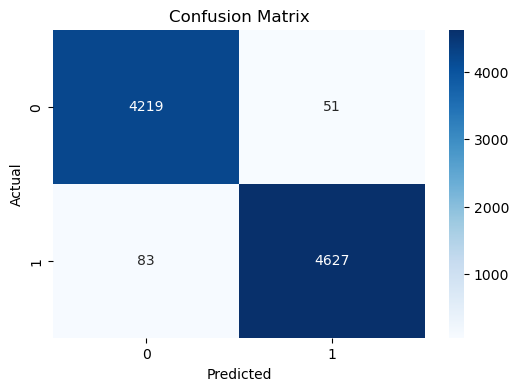

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 12. Model Comparison using Multinomial Naive Bayes

To compare performance, a Multinomial Naive Bayes classifier is trained on the same TF-IDF features. This allows comparison between a probabilistic model and Logistic Regression.

In [26]:
from sklearn.naive_bayes import MultinomialNB

# Initialize model
nb_model = MultinomialNB()

# Train model
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)

# Accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9280623608017817

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      4270
           1       0.93      0.93      0.93      4710

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980

